In [10]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
def f(x):
    return 3*x**2 -4*x + 5

In [8]:
f(3.0)

20.0

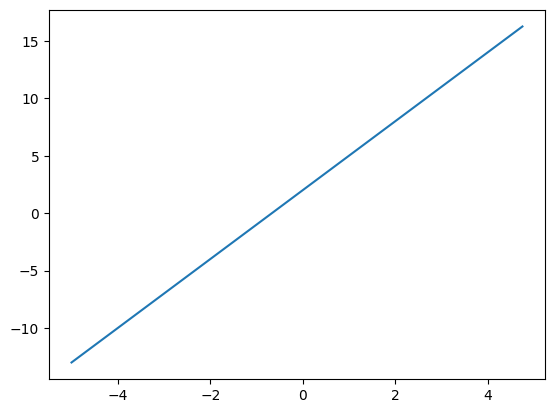

In [13]:
def f1(x): 
    return 3*x + 2

xs = np.arange(-5, 5, 0.25)
ys = f1(xs)
plt.plot(xs, ys)


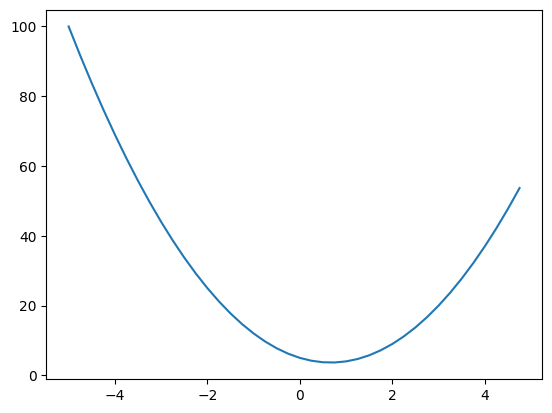

In [5]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [9]:
h = 0.00000001
x = 2/3
(f(x + h) - f(x))/h 

0.0

In [14]:
# h is the height at a given point in time
h = 0.0001

a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
# effect of increasing a by h
a += h
# effect of increasing a by h
# b += h
# effect of increasing a by h
# c += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
# This will give the slope or rate of change at a given h w.r.t to change in either a, b or c(i.e, derivative of d w.r.t to that variable)
print('slope' , (d2-d1)/h)

'''
Slope is -3.0 for the derivative of d w.r.t to change in a as we can see it went from 4.0(d1) to 3.999(d2) 
with a small movement in h giving a negative slope

d1 4.0
d2 3.999699999999999
slope -3.000000000010772
'''


d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [51]:
class Value:
  
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"
  
  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')
    
    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward
    
    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')
    
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
      
    return out
  
  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')

    def _backward():
        self.grad += other * (self.data ** (other - 1)) * out.grad
    out._backward = _backward

    return out
  
  def __rmul__(self, other): # other * self
    return self * other

  def __truediv__(self, other): # self / other
    return self * other**-1

  def __neg__(self): # -self
    return self * -1

  def __sub__(self, other): # self - other
    return self + (-other)

  def __radd__(self, other): # other + self
    return self + other

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')
    
    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    
    return out
  
  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')
    
    def _backward():
      self.grad += out.data * out.grad # NOTE: in the video I incorrectly used = instead of +=. Fixed here.
    out._backward = _backward
    
    return out
  
  
  def backward(self):
    
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

In [30]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

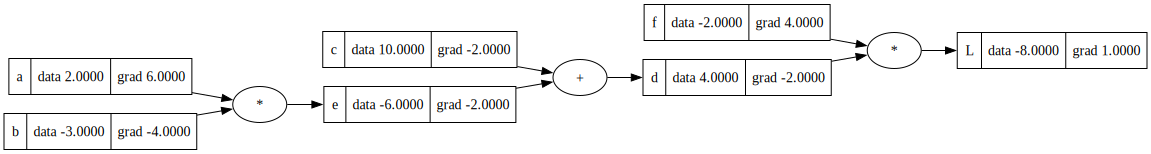

In [15]:
draw_dot(L)

In [60]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

"""
dL/dx2 = dL/dx2w2 * dx2w2/dx2
x2.grad= x2w2.grad * derivative of(x2*w2) w.r.t x2 => w2 = w2.data
x2.grad= 0.5 * 1.0 = 0.5
"""

'\ndL/dx2 = dL/dx2w2 * dx2w2/dx2\nx2.grad= x2w2.grad * derivative of(x2*w2) w.r.t x2 => w2 = w2.data\nx2.grad= 0.5 * 1.0 = 0.5\n'

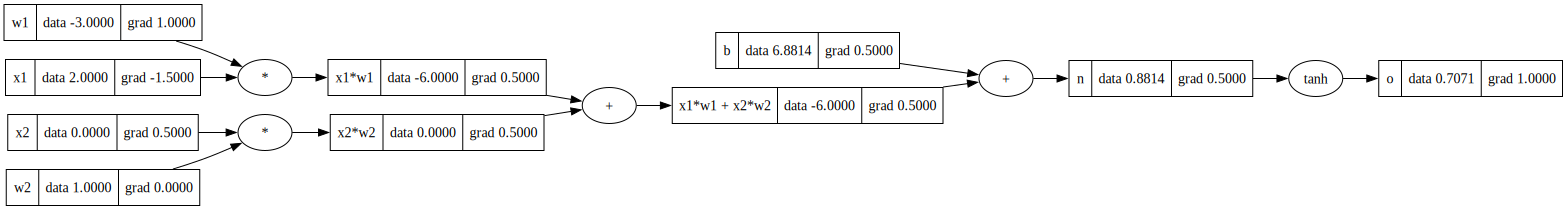

In [58]:
draw_dot(o)

In [57]:
o.backward()

In [6]:
import random

In [60]:
class Neuron:
    
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        # w*x + b
        act = sum((xi*wi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

class Layer:
    
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]
    
class MLP:
  
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]      

In [227]:
x = [1.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=-0.4352887692436464)

In [63]:
n.parameters()

[Value(data=-0.5922674569153488),
 Value(data=0.864300627843712),
 Value(data=0.4252571769412796),
 Value(data=-0.8888090898688841),
 Value(data=0.41428443649516566),
 Value(data=0.40100755470387983),
 Value(data=-0.6946965438664638),
 Value(data=0.14040601588968427),
 Value(data=-0.6280641977607153),
 Value(data=-0.5290361922723514),
 Value(data=0.06837265014554883),
 Value(data=-0.09097105932245664),
 Value(data=0.4312133801763065),
 Value(data=0.60734035887153),
 Value(data=-0.8322262891867),
 Value(data=-0.2086138925403178),
 Value(data=-0.9948493728604257),
 Value(data=0.14113014455594874),
 Value(data=-0.494292134174835),
 Value(data=0.058601041109878294),
 Value(data=0.2474281452345981),
 Value(data=0.6727606503939925),
 Value(data=-0.4150948389597553),
 Value(data=0.1058373237434651),
 Value(data=-0.3132302242548284),
 Value(data=0.038579035659083605),
 Value(data=0.266752987284296),
 Value(data=0.3036902095617189),
 Value(data=0.07858361754156262),
 Value(data=0.37115004418405

In [224]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [301]:
for k in range(20):
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
    
    # backward pass
    # setting all the grad to 0 before every backward pass, otherwise it all adds up as per our Value AutoGrad class.
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    # update
    for p in n.parameters():
        p.data += -0.1 * p.grad
    print(k, loss.data)
    

0 0.00021040567525583466
1 0.0002101784349986793
2 0.00020995167897765605
3 0.0002097254056590153
4 0.00020949961351543828
5 0.00020927430102600603
6 0.00020904946667615824
7 0.0002088251089576761
8 0.00020860122636863216
9 0.00020837781741336203
10 0.00020815488060244873
11 0.00020793241445265847
12 0.00020771041748694305
13 0.00020748888823438205
14 0.00020726782523016157
15 0.0002070472270155435
16 0.0002068270921378306
17 0.0002066074191503461
18 0.0002063882066123771
19 0.00020616945308917192


In [302]:
ypred

[Value(data=0.9932962686697553),
 Value(data=-0.9939954643372318),
 Value(data=-0.9938344689506479),
 Value(data=0.990663982771273)]